# Example of DFT calculation with Ecut and K-point convergence
# NSCI0032/2025-2026 - Term 1

## Import various libraries 

In [1]:
import os, re, time
import pandas as pd
import matplotlib.pyplot as plt

# The Pseudo Potentials, and general setup

In [2]:
pp_dir  = "/home/jovyan/espresso/pseudo"
pp_file = "Cu.pbe-dn-kjpaw_psl.1.0.0.UPF"
pp_path = f"{pp_dir}/{pp_file}"

os.makedirs(pp_dir, exist_ok=True)

if not os.path.exists(pp_path):
    !wget -q https://pseudopotentials.quantum-espresso.org/upf_files/{pp_file} -O {pp_path}

In [3]:
ry_to_mev = 13605.698  # unit conversion

# QE Input file template

In [13]:
template = f"""&control
    calculation='scf',
    prefix='cu',
    outdir='./tmp',
    pseudo_dir='{pp_dir}'
    verbosity='high'
/
&system
    ibrav=2, celldm(1)=6.63,
    nat=1, ntyp=1,
    ecutwfc={{ecut}},
    occupations='smearing',
    smearing='mv',
    degauss=0.02
/
&electrons
    conv_thr=1.0d-1
/
ATOMIC_SPECIES
 Cu 63.546 {pp_file}
ATOMIC_POSITIONS crystal
 Cu 0.0 0.0 0.0
K_POINTS automatic
 {{k}} {{k}} {{k}} 1 1 1
"""

# K point sampling and Convergence

In [14]:
k_list = [2, 4, 6, 8, 10]
ecut_fixed = 40
os.makedirs("kconv", exist_ok=True)

ener_k = {}
time_k = {}

In [15]:
for k in k_list:
    infile  = f"kconv/cu_k{k}.in"
    outfile = f"kconv/cu_k{k}.out"

    with open(infile, "w") as f:
        f.write(template.format(k=k, ecut=ecut_fixed))

    t0 = time.time()
    !pw.x < {infile} > {outfile}
    t1 = time.time()

    with open(outfile) as f:
        txt = f.read()

    m = re.findall(r"!\s+total energy\s*=\s*([-\d\.E+]+)", txt)
    ener_k[k] = float(m[-1])
    time_k[k] = t1 - t0

In [16]:
print(ener_k)

{2: -212.97763288, 4: -213.03366727, 6: -213.04035642, 8: -213.0415114, 10: -213.04117775}


In [17]:
df_k = pd.DataFrame({
    "k": k_list,
    "Energy (Ry)":       [ener_k[k] for k in k_list],
    "Energy (meV)":      [ener_k[k] * ry_to_mev for k in k_list],
    "CPU Time (s)":      [time_k[k] for k in k_list]
})
df_k["Delta E (meV)"] = df_k["Energy (meV)"].diff()

print("# k-POINT CONVERGENCE")
display(df_k)

# k-POINT CONVERGENCE


,k,Energy (Ry),Energy (meV),CPU Time (s),Delta E (meV)
0,2,-212.977633,-2.897709e+06,3.976887,NaN
1,4,-213.033667,-2.898472e+06,4.389699,-762.386988
2,6,-213.040356,-2.898563e+06,4.536628,-91.010555
3,8,-213.041511,-2.898578e+06,5.458087,-15.714309
4,10,-213.041178,-2.898574e+06,7.159997,4.539541


In [18]:
ecut_list = [20, 30, 40, 50, 60, 80]
k_fixed = 6
os.makedirs("ecutconv", exist_ok=True)

In [19]:
ener_ecut = {}
time_ecut = {}

for ecut in ecut_list:
    infile  = f"ecutconv/cu_ecut{ecut}.in"
    outfile = f"ecutconv/cu_ecut{ecut}.out"

    with open(infile, "w") as f:
        f.write(template.format(k=k_fixed, ecut=ecut))

    t0 = time.time()
    !pw.x < {infile} > {outfile}
    t1 = time.time()

    with open(outfile) as f:
        txt = f.read()

    m = re.findall(r"!\s+total energy\s*=\s*([-\d\.E+]+)", txt)
    ener_ecut[ecut] = float(m[-1])
    time_ecut[ecut] = t1 - t0

In [20]:
df_ecut = pd.DataFrame({
    "ecut (Ry)":         ecut_list,
    "Energy (Ry)":       [ener_ecut[e] for e in ecut_list],
    "Energy (meV)":      [ener_ecut[e] * ry_to_mev for e in ecut_list],
    "CPU Time (s)":      [time_ecut[e] for e in ecut_list]
})
df_ecut["Delta E (meV)"] = df_ecut["Energy (meV)"].diff()

print("# E_{cut} Convergence")
display(df_ecut)

# E_{cut} Convergence


,ecut (Ry),Energy (Ry),Energy (meV),CPU Time (s),Delta E (meV)
0,20,-212.390717,-2.889724e+06,4.296259,NaN
1,30,-213.020581,-2.898294e+06,5.652205,-8569.734195
2,40,-213.040356,-2.898563e+06,4.430077,-269.061930
3,50,-213.041490,-2.898578e+06,6.739119,-15.421514
4,60,-213.042379,-2.898590e+06,7.037425,-12.099683
5,80,-213.042556,-2.898593e+06,8.625032,-2.406304


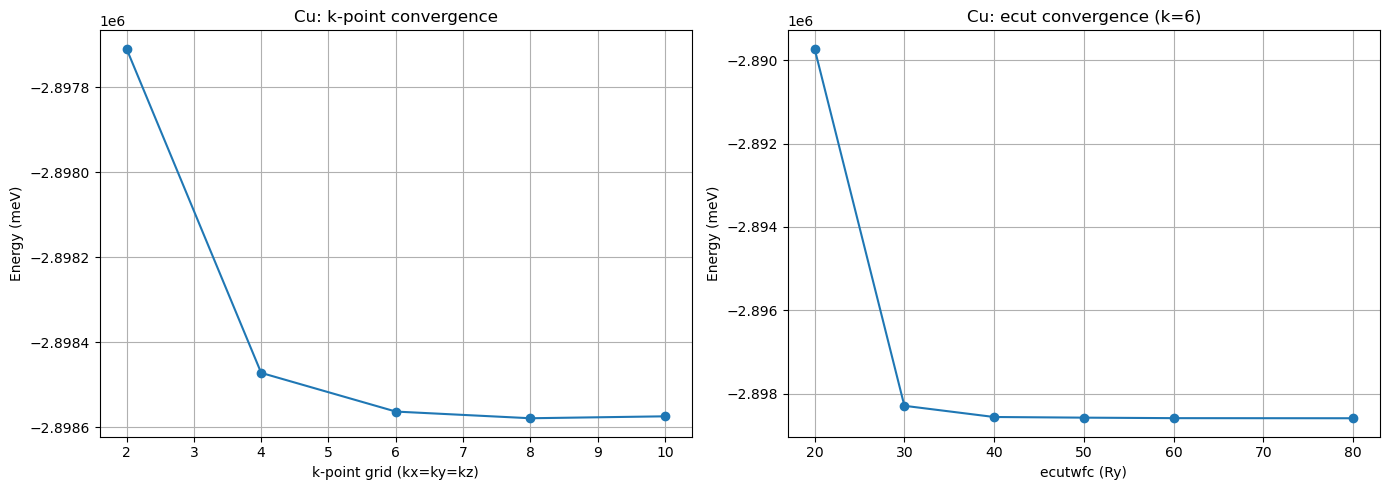

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# k-points
ax[0].plot(df_k["k"], df_k["Energy (meV)"], marker="o")
ax[0].set_xlabel("k-point grid (kx=ky=kz)")
ax[0].set_ylabel("Energy (meV)")
ax[0].set_title("Cu: k-point convergence")
ax[0].grid(True)

# ecut
ax[1].plot(df_ecut["ecut (Ry)"], df_ecut["Energy (meV)"], marker="o")
ax[1].set_xlabel("ecutwfc (Ry)")
ax[1].set_ylabel("Energy (meV)")
ax[1].set_title(f"Cu: ecut convergence (k={k_fixed})")
ax[1].grid(True)

plt.tight_layout()
plt.show()